Total frames: 1074

0: 384x640 1 person, 78.7ms
Speed: 6.8ms preprocess, 78.7ms inference, 2.3ms postprocess per image at shape (1, 3, 384, 640)


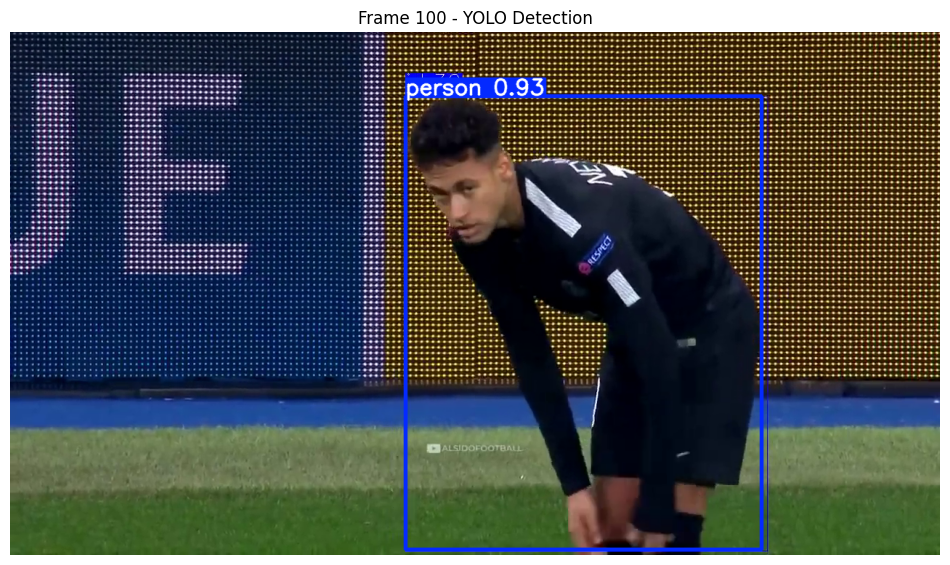


Detections found: 1
  person: 0.93


In [ ]:
import cv2
from ultralytics import YOLO
import matplotlib.pyplot as plt

# Load pre-trained model
model = YOLO('yolo11n.pt')

# Open the downloaded video file
video_path = 'soccer.mp4'
cap = cv2.VideoCapture(video_path)

# Check if video opened successfully
if not cap.isOpened():
    print("Error: Could not open video file")
else:
    # Select a frame
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f"Total frames: {total_frames}")
    
    frame_number = 100
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)
    
    # Read the frame
    ret, frame = cap.read()
    cap.release()
    
    if ret:
        # Run YOLO on the frame
        results = model(frame)
        
        # Visualize results
        annotated_frame = results[0].plot()
        
        # Display detection result with frame
        plt.figure(figsize=(12, 8))
        plt.imshow(cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.title(f'Frame {frame_number} - YOLO Detection')
        plt.show()
        
        print(f"\nDetections found: {len(results[0].boxes)}")
        for box in results[0].boxes:
            class_id = int(box.cls[0])
            class_name = model.names[class_id]
            confidence = float(box.conf[0])
            print(f"  {class_name}: {confidence:.2f}")
    else:
        print("Failed to read frame")